<a href="https://colab.research.google.com/github/kundanmrj5-dev/Flyrrank-ml-Internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kundanmrj5-dev/Flyrrank-ml-Internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

Which anonymized content pages should a content team review first for a possible refresh? This supports a human decision about review priority; it does not promise that refreshing a page will increase traffic.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

Data: I use the public, anonymized content_refresh_anonymized.csv starter release. It has one row per content page and trailing-90-day metrics; there are no tables to join. This is a snapshot, not daily time-series data, so I will compare the baseline and model on the same rows and split. IDs are for identification or grouping only, not model features. I exclude trend_direction, trend_pct, and is_declining_label from model inputs because they are label-derived. The notebook contains no client names, URLs, or private queries.

In [11]:
import pandas as pd

DATA_URL = (
    "https://raw.githubusercontent.com/"
    "kundanmrj5-dev/Flyrrank-ml-Internship/main/"
    "data/raw/content_refresh_anonymized.csv"
)

capstone_data = pd.read_csv(DATA_URL)

print("Rows and columns:", capstone_data.shape)
print("Unique content pages:", capstone_data["content_id"].nunique())
print("Date window: trailing 90 days, as supplied in the snapshot")
display(capstone_data.head())

Rows and columns: (30000, 44)
Unique content pages: 30000
Date window: trailing 90 days, as supplied in the snapshot


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

Label: I use trend_direction == "down" as a proxy for a page with declining search impressions. It describes the supplied snapshot; it does not prove a cause or predict future decline.
Features: I use page age, time since update, search impressions, clicks, sessions, CTR, average position, search volume, and content categories. I exclude IDs from model inputs and exclude trend_direction, trend_pct, and the decline label from features. Position value 0 is treated as missing.
Baseline: I compare the model with my transparent rule: review pages at least 180 days since update with at least 500 impressions, ranked by impressions.
Validation: I hold out clients using a client-grouped split and compare both methods on the same held-out rows. I report Precision@20 and Precision@50 with the held-out label base rate. Results are decision-support only.

In [12]:
import numpy as np
from sklearn.model_selection import GroupShuffleSplit

# Create the proxy label. Keep trend_direction out of model features.
y = capstone_data["trend_direction"].eq("down").astype("int8")

numeric_features = [
    "content_age_days",
    "days_since_last_update",
    "impressions_90d",
    "clicks_90d",
    "sessions_90d",
    "ctr",
    "avg_position",
    "search_volume",
]

categorical_features = [
    "content_type",
    "main_intent",
    "competition_level",
]

feature_cols = numeric_features + categorical_features

forbidden_features = {
    "content_id",
    "client_id",
    "trend_direction",
    "trend_pct",
    "is_declining_label",
}

assert not (set(feature_cols) & forbidden_features)
missing = [c for c in feature_cols if c not in capstone_data.columns]
if missing:
    raise ValueError(f"Missing expected feature columns: {missing}")

# IDs are used only to keep each client in one split.
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(
    splitter.split(
        capstone_data[feature_cols],
        y,
        groups=capstone_data["client_id"],
    )
)

print("Feature count:", len(feature_cols))
print("Training rows:", len(train_idx))
print("Held-out rows:", len(test_idx))
print("Held-out client groups:",
      capstone_data.iloc[test_idx]["client_id"].nunique())
print("Held-out decline-proxy rate:",
      round(float(y.iloc[test_idx].mean()), 3))

Feature count: 11
Training rows: 23837
Held-out rows: 6163
Held-out client groups: 7
Held-out decline-proxy rate: 0.511


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

X = capstone_data[feature_cols].copy()

# In this dataset, zero means average position is unavailable.
X["avg_position"] = X["avg_position"].replace(0, np.nan)

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features),
])

model = Pipeline([
    ("prepare", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced")),
])

model.fit(X.iloc[train_idx], y.iloc[train_idx])
model_scores = model.predict_proba(X.iloc[test_idx])[:, 1]

# Recreate the Week 4 rule on the exact same held-out rows.
test_rows = capstone_data.iloc[test_idx]
stale = test_rows["days_since_last_update"].ge(180).fillna(False)
visible = test_rows["impressions_90d"].ge(500).fillna(False)
baseline_scores = np.where(stale & visible, test_rows["impressions_90d"], 0)

y_test = y.iloc[test_idx].to_numpy()

def precision_at_k(labels, scores, k):
    order = np.argsort(-np.asarray(scores), kind="stable")
    k = min(k, len(order))
    return float(np.asarray(labels)[order[:k]].mean())

results = pd.DataFrame([
    {
        "method": "Rule baseline",
        "Precision@20": precision_at_k(y_test, baseline_scores, 20),
        "Precision@50": precision_at_k(y_test, baseline_scores, 50),
    },
    {
        "method": "Logistic regression",
        "Precision@20": precision_at_k(y_test, model_scores, 20),
        "Precision@50": precision_at_k(y_test, model_scores, 50),
    },
])

display(results.round(3))
print("Held-out base rate:", round(float(y_test.mean()), 3))

,method,Precision@20,Precision@50
0,Rule baseline,0.80,0.70
1,Logistic regression,0.65,0.52


Held-out base rate: 0.511


## 5. Limitations

*What this work cannot claim.*

This dataset is a single anonymized snapshot with trailing-90-day summaries, so this evaluation does not prove performance on future dates. The decline label is a proxy, not a confirmed cause. A page may have high impressions because of seasonality or search-intent changes, and an old update date alone does not prove its content needs refreshing. The client-grouped holdout reduces client overlap, but this result still needs human review and future-period validation before any real action.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

I rank the held-out pages by the model’s score for the decline proxy. The top 20 are suggestions for human review, not predictions of future performance or automatic refresh instructions. Each row includes a reason code and a note about why the recommendation could be wrong.

In [14]:
ranked_recommendations = test_rows.copy().reset_index(drop=True)
ranked_recommendations["model_score"] = model_scores
ranked_recommendations["baseline_score"] = baseline_scores

stale = ranked_recommendations["days_since_last_update"].ge(180).fillna(False)
visible = ranked_recommendations["impressions_90d"].ge(500).fillna(False)

ranked_recommendations["reason_code"] = np.select(
    [
        stale & visible,
        stale & ~visible,
        ~stale & visible,
    ],
    [
        "stale_and_visible",
        "stale_low_visibility",
        "visible_but_not_confirmed_stale",
    ],
    default="other_review_candidate",
)

ranked_recommendations["action"] = "human_review_before_refresh"
ranked_recommendations["confidence_note"] = (
    "Ranks the observed proxy only; not a future-performance probability."
)
ranked_recommendations["what_could_make_it_wrong"] = (
    "Seasonality or changed search intent could explain the observed signals."
)

top20_recommendations = (
    ranked_recommendations
    .sort_values("model_score", ascending=False)
    .head(20)
)

display(top20_recommendations[[
    "content_id",
    "model_score",
    "baseline_score",
    "reason_code",
    "action",
    "confidence_note",
    "what_could_make_it_wrong",
]])

,content_id,model_score,baseline_score,reason_code,action,confidence_note,what_could_make_it_wrong
3745,content_b08562686d22,0.749102,0,visible_but_not_confirmed_stale,human_review_before_refresh,Ranks the observed proxy only; not a future-pe...,Seasonality or changed search intent could exp...
5754,content_26d48a980581,0.746436,0,visible_but_not_confirmed_stale,human_review_before_refresh,Ranks the observed proxy only; not a future-pe...,Seasonality or changed search intent could exp...
1480,content_829c68e60d13,0.745861,0,other_review_candidate,human_review_before_refresh,Ranks the observed proxy only; not a future-pe...,Seasonality or changed search intent could exp...
589,content_b925c292d21b,0.739582,0,other_review_candidate,human_review_before_refresh,Ranks the observed proxy only; not a future-pe...,Seasonality or changed search intent could exp...
5702,content_84c5f6af423c,0.738093,0,other_review_candidate,human_review_before_refresh,Ranks the observed proxy only; not a future-pe...,Seasonality or changed search intent could exp...
2892,content_e5b7ee456c43,0.737001,0,visible_but_not_confirmed_stale,human_review_before_refresh,Ranks the observed proxy only; not a future-pe...,Seasonality or changed search intent could exp...
4624,content_6ac3ab740bbf,0.733512,0,visible_but_not_confirmed_stale,human_review_before_refresh,Ranks the observed proxy only; not a future-pe...,Seasonality or changed search intent could exp...
4627,content_ef9bdd92b523,0.733300,0,other_review_candidate,human_review_before_refresh,Ranks the observed proxy only; not a future-pe...,Seasonality or changed search intent could exp...
2567,content_624b2fd8dca5,0.731906,0,other_review_candidate,human_review_before_refresh,Ranks the observed proxy only; not a future-pe...,Seasonality or changed search intent could exp...
3623,content_1de940de6ed3,0.728455,0,other_review_candidate,human_review_before_refresh,Ranks the observed proxy only; not a future-pe...,Seasonality or changed search intent could exp...


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

I create a comparison chart and metrics table from the same held-out split used in the results section. These artifacts report measured results for the decline proxy; they do not establish future performance.

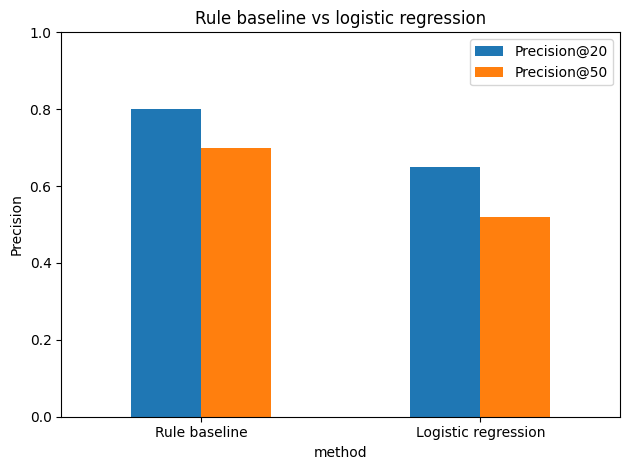

Saved metrics: work/outputs/capstone_metrics.csv
Saved chart: work/outputs/capstone_precision_comparison.png
Saved top-20 queue: work/outputs/capstone_top20_recommendations.csv


In [15]:
from pathlib import Path
import matplotlib.pyplot as plt

artifact_dir = Path("work/outputs")
artifact_dir.mkdir(parents=True, exist_ok=True)

# Save the actual comparison table and chart.
results.to_csv(artifact_dir / "capstone_metrics.csv", index=False)

ax = results.set_index("method")[["Precision@20", "Precision@50"]].plot(
    kind="bar",
    ylim=(0, 1),
    ylabel="Precision",
    title="Rule baseline vs logistic regression",
    rot=0,
)
ax.figure.tight_layout()
chart_path = artifact_dir / "capstone_precision_comparison.png"
ax.figure.savefig(chart_path, dpi=160, bbox_inches="tight")
plt.show()

# Save the top-20 recommendations as a regenerable output.
top20_recommendations.to_csv(
    artifact_dir / "capstone_top20_recommendations.csv",
    index=False,
)

print("Saved metrics:", artifact_dir / "capstone_metrics.csv")
print("Saved chart:", chart_path)
print("Saved top-20 queue:", artifact_dir / "capstone_top20_recommendations.csv")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
